# **SCRIPT TO MERGE ICONICITY EMBEDDINGS**

This script is responsible for receiving the embeddings from the models (**MHI-Only, signERT and MHI-signERT**) and performing the merge with the iconicity that corresponds to each gloss according to the type of sign language **LSP (Peruvian Sign Language), ASL (American Sign Language)**

## **INPUT FILES**

### Type of Phonological Embedding :

#### Files base to process:
embeddings_fonologico: https://drive.google.com/drive/u/0/folders/1alwK9yfusT6SLUQrJWYP9ud2Aj7GUEsy


*   MHI-Only: gets the emedding from the Movement Historic Image
    1.   ASL: phonoEmbedding_median_ASL_MHIv3.csv
    2.   LSP: phonoEmbedding_median_LSP_MHIv3.csv

*   signERT: gets the embedding from the very previous to the last layer form the model signERT
    1.   ASL: phonoEmbedding_median_ASL_signERTv1.csv
    2.   LSP: phonoEmbedding_median_LSP_signERTv1.csv

*   MHI-signERT:  gets the embedding by combining MHI and the keypoints
    1.   ASL: phonoEmbedding_median_ASL_MHIv3signERTv1.csv
    2.   LSP: phonoEmbedding_median_LSP_MHIv3signERTv1.csv
    


### Type of Semantic Embedding

### Files base to process:  

embeddings_semantico: https://drive.google.com/drive/u/0/folders/1Jm0zWxSeF10gFiLHKJyBQNY1LVJZJToo


*   ASL: semanticEmbedding_RAW_ASL_FASTTEXT.csv
*   LSP: semanticEmbedding_RAW_LSP_FASTTEXT.csv


For iconicity: https://drive.google.com/drive/u/0/folders/1XXa2HF6XqCyukJ3b3LfuYyRowfLXWm_k

* ASL and LSP: iconicity_all.csv

For translate:
words_translate.csv






## **OUTPUTS SCRIPT FOR  MERGE  ICONICITY + EMBEDDINGS**

### Type of Phonological Embedding , the files will have the following names examples:

*   MHI-Only: gets the emedding from the Movement Historic Image
    1.   ASL: emb_phono_median_ASL_MHIv3.csv
    2.   LSP: emb_phono_median_LSP_MHIv3.csv
*   signERT: gets the embedding from the very previous to the last layer form the model signERT
    1.   ASL: emb_phono_median_ASL_signERTv1.csv
    2.   LSP: emb_phono_median_LSP_signERTv1.csv
*   MHI-signERT:  gets the embedding by combining MHI and the keypoints
    1.   ASL: emb_phono_median_ASL_MHIv3signERTv1.csv
    2.   LSP: emb_phono_median_LSP_MHIv3signERTv1.csv

### Type of Semantic Embedding

*   ASL: emb_semantic_RAW_ASL_FASTTEXT.csv
*   LSP: emb_semantic_RAW_LSP_FASTTEXT.csv

In [1]:
"""
Iconicity MERGE SCRIPT + EMBEDDINGS

Supports ALL formats:
- LSP, ASL signERTv (ASL_GLOSS LSP_GLOSS, 0-191)
- LSP, ASL MHIv (ASL_GLOSS LSP_GLOSS, 0-4063)
- FastText ASL (ASL_GLOSS LSP_GLOSS, 0-299)
- FastText LSP (ASL_GLOSS LSP_GLOSS, 0-299)

The script automatically detects and adds the iconicity column for ASL or LSP as appropriate.
"""

'\nIconicity MERGE SCRIPT + EMBEDDINGS\n\nSupports ALL formats:\n- LSP, ASL signERTv (ASL_GLOSS LSP_GLOSS, 0-191)\n- LSP, ASL MHIv (ASL_GLOSS LSP_GLOSS, 0-4063)\n- FastText ASL (ASL_GLOSS LSP_GLOSS, 0-299)\n- FastText LSP (ASL_GLOSS LSP_GLOSS, 0-299)\n\nThe script automatically detects and adds the iconicity column for ASL or LSP as appropriate.\n'

In [2]:
import pandas as pd
pd.set_option('display.max_rows', None)

In [3]:
# ============================================================================
# STEP 1: Upload the Embeddings File and set the Input and Output names
# ============================================================================

signLanguage = "LSP" #LSP #ASL
embeddingType = "emb_phono"
modelType = "MHIv5" #signERTv1 #MHIv3 #MHIv3signERTv1, signERTv2, MHIv5, MHIv5signERTv1, MHIv5signERTv2
method = "median" #median #zscore #minmax #normalL2
processName = "phonoEmbedding"

emb_length = {"signERTv1":192,
              "MHIv5":4064,
              "MHIv5signERTv1":4256,
              "FASTTEXT":300}

# Read the embeddings file
input_filename = f"{processName}_{method}_{signLanguage}_{modelType}.csv"
embedding_cols = [i for i in range(emb_length[modelType])] #semantic 300 # phonological : #192 #4064 # 4256

# Rename embeddings if necessary or semantic embedding (v0 → 0, v1 → 1, etc.), if it is phonological False
needs_rename = False
if needs_rename:
  embedding_cols = ['v'+str(i) for i in range(len(embedding_cols))]

df_embeddings = pd.read_csv(input_filename)

output_filename = f"{embeddingType}_{method}_{signLanguage}_{modelType}.csv"

print(f"   the final file will be called: {output_filename}")

   the final file will be called: emb_phono_median_LSP_MHIv5.csv


In [4]:
df_embeddings

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4054,4055,4056,4057,4058,4059,4060,4061,4062,4063
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,-0.008997,-0.013320,0.037881,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,-0.013641,0.030990,-0.013403,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.013560,-0.013144,-0.007097,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004
3,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,0.024008,...,-0.000725,-0.013545,0.048494,-0.014037,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404
4,JUMP,SALTAR,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,0.024953,...,-0.011201,0.015393,-0.013316,0.005038,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027
5,CRAB,CANGREJO,-0.000230,0.004610,0.000303,-0.001717,0.005218,-0.000117,0.005041,0.018478,...,0.010776,0.034488,-0.012879,0.055246,-0.010730,0.004235,-0.011674,-0.012678,-0.003976,-0.012593
6,TRAIN,TREN,0.000695,0.003516,0.000988,-0.003550,0.001115,-0.000909,0.000837,0.021099,...,-0.013001,0.044891,-0.012767,0.028491,0.014273,0.024521,-0.011568,-0.012568,-0.012414,-0.012482
7,TURTLE,TORTUGA,-0.002859,0.006973,-0.002321,-0.001417,0.004899,-0.000660,0.004051,0.023542,...,-0.013869,-0.005728,0.020447,-0.013941,-0.013118,-0.003672,-0.012390,-0.013423,0.003891,0.042555
8,TABLE,MESA,-0.002146,0.004464,-0.001335,-0.001994,0.007123,0.000926,0.003323,0.023281,...,-0.013658,-0.000201,-0.013419,0.012810,-0.012911,0.033435,-0.012189,-0.013214,0.021796,-0.013130
9,BORN,NACER,-0.001762,0.005993,-0.000882,-0.001804,0.002392,-0.000137,0.005733,0.024489,...,0.038299,0.012524,0.071545,-0.013996,-0.013172,-0.013582,-0.012442,-0.009907,-0.013318,0.012342


In [5]:
# ============================================================================
# STEP 2: READING TRANSLATE FILE
# ============================================================================

df_translate = pd.read_csv('words_translate.csv', usecols=[0, 1])
print(f" File uploaded: {len(df_translate)} words")
print(f" Columns: {list(df_translate.columns)}")
df_translate.head(5)

 File uploaded: 105 words
 Columns: ['EnglishGloss', 'SpanishGloss']


,EnglishGloss,SpanishGloss
0,BABY,BEBÉ
1,HOUSE,CASA
2,GROW,CRECER
3,SMOKE,FUMAR
4,WORM,GUSANO


In [6]:
# ============================================================================
# STEP 3: READING ICONICITY FILE
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 9


#### Reading Iconicity file
df_iconicity = pd.read_csv('iconicity_all.csv')
df_iconicity['ASL_GLOSS'] = df_iconicity['ASL_GLOSS'].str.strip().str.upper()
# df_iconicity['lsp_word'] = df_iconicity['lsp_word'].str.strip().str.upper()
df_iconicity['LSP_GLOSS'] = df_iconicity['LSP_GLOSS'].str.strip().str.upper()

print(f" File Uploaded: {len(df_iconicity)} words")
print(f" Columns: {list(df_iconicity.columns)}")
df_iconicity.head(5)



 File Uploaded: 105 words
 Columns: ['ASL_GLOSS', 'ASL_ICONICITY', 'LSP_GLOSS', 'LSP_ICONICITY']


,ASL_GLOSS,ASL_ICONICITY,LSP_GLOSS,LSP_ICONICITY
0,BABY,3.820513,BEBÉ,4.254902
1,HOUSE,4.410256,CASA,4.764706
2,GROW,3.897436,CRECER,4.058823
3,SMOKE,4.717949,FUMAR,4.803922
4,WORM,3.384615,GUSANO,4.215686



ASL STATISTICS
       Mean: 3.672
     Median: 3.538
        Std: 0.526
        Min: 2.692
        Max: 4.897

LSP STATISTICS
       Mean: 4.360
     Median: 4.412
        Std: 0.364
        Min: 2.922
        Max: 4.902

SAVING IMAGE
   ✓ Image saved: iconicity_histograms_ASL_LSP.png
   ✓ Type detected: PNG
   ✓ Resolution: 300 DPI
   ✓ Bins: 10 bins with 0.25 intervals
   ✓ Ranges: 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0
   ✓ Total words analyzed: 105
   ✓ Downloading file...

 Process completed successfully!


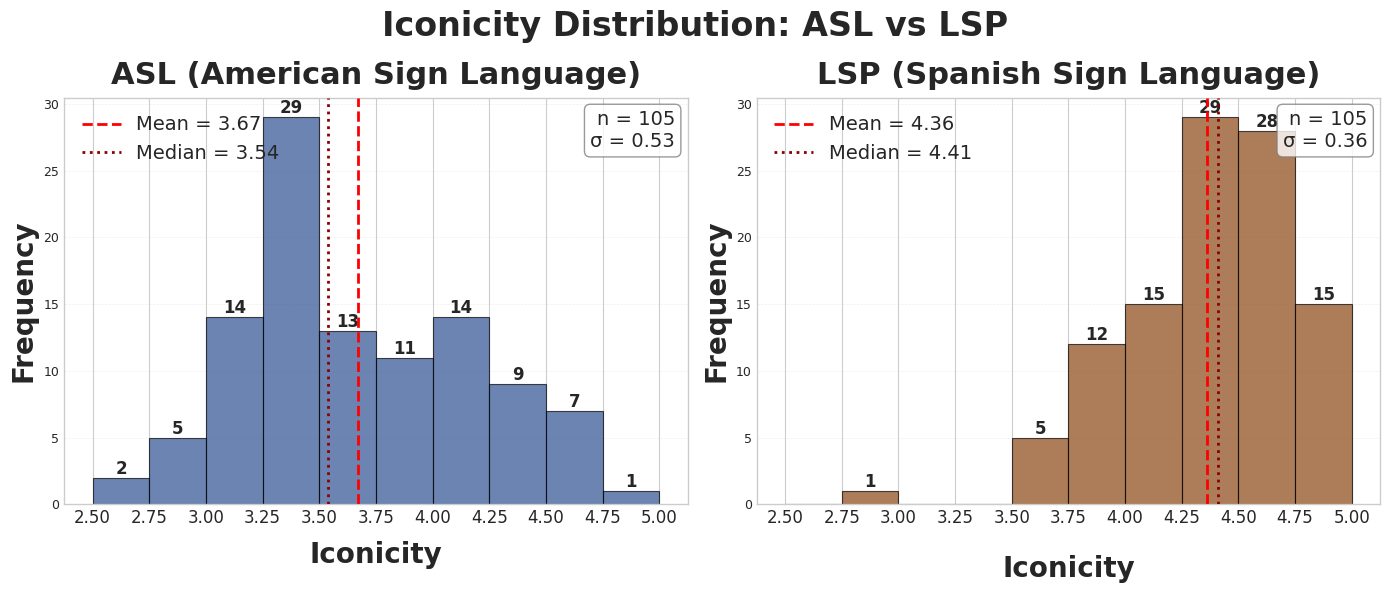


BIN DETAILS - ASL
Bin #    Range                Frequency   
----------------------------------------------------------------------
1        2.50 - 2.75         2           
2        2.75 - 3.00         5           
3        3.00 - 3.25         14          
4        3.25 - 3.50         29          
5        3.50 - 3.75         13          
6        3.75 - 4.00         11          
7        4.00 - 4.25         14          
8        4.25 - 4.50         9           
9        4.50 - 4.75         7           
10       4.75 - 5.00         1           

BIN DETAILS - LSP
Bin #    Range                Frequency   
----------------------------------------------------------------------
1        2.50 - 2.75         0           
2        2.75 - 3.00         1           
3        3.00 - 3.25         0           
4        3.25 - 3.50         0           
5        3.50 - 3.75         5           
6        3.75 - 4.00         12          
7        4.00 - 4.25         15          
8        4.25 - 4.50

In [32]:
# ============================================================================
# STEP 4: ICONICITY ANALYSIS
# ============================================================================

# Extract iconicity data
asl_iconicity = df_iconicity['ASL_ICONICITY']
lsp_iconicity = df_iconicity['LSP_ICONICITY']

# Calculate ASL statistics
asl_stats = {
    'mean': asl_iconicity.mean(),
    'median': asl_iconicity.median(),
    'std': asl_iconicity.std(),
    'min': asl_iconicity.min(),
    'max': asl_iconicity.max()
}

# Calculate LSP statistics
lsp_stats = {
    'mean': lsp_iconicity.mean(),
    'median': lsp_iconicity.median(),
    'std': lsp_iconicity.std(),
    'min': lsp_iconicity.min(),
    'max': lsp_iconicity.max()
}

print("\n" + "="*70)
print("ASL STATISTICS")
print("="*70)
for key, value in asl_stats.items():
    print(f"   {key.capitalize():>8}: {value:.3f}")

print("\n" + "="*70)
print("LSP STATISTICS")
print("="*70)
for key, value in lsp_stats.items():
    print(f"   {key.capitalize():>8}: {value:.3f}")

# ============================================================================
# CREATING HISTOGRAMS
# ============================================================================
# Bins of 0.25 (10 bins)
bins_custom = [2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0]
n_bins = len(bins_custom) - 1

# Two subplots is created
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Iconicity Distribution: ASL vs LSP',
             fontsize=24, fontweight='bold', y=0.98)
color_asl = '#2E5090'
color_lsp = '#8B4513'

# ===== HISTOGRAM ASL =====
ax1 = axes[0]
counts_asl, bins_asl, patches_asl = ax1.hist(asl_iconicity, bins=bins_custom,
                                              color=color_asl, alpha=0.7,
                                              edgecolor='black', linewidth=0.8)

for i, (count, patch) in enumerate(zip(counts_asl, patches_asl)):
    if count > 0:
        height = patch.get_height()
        ax1.text(patch.get_x() + patch.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Average and median lines for ASL
ax1.axvline(asl_stats['mean'], color='red', linestyle='--',
           linewidth=2, label=f"Mean = {asl_stats['mean']:.2f}", zorder=5)
ax1.axvline(asl_stats['median'], color='darkred', linestyle=':',
           linewidth=2, label=f"Median = {asl_stats['median']:.2f}", zorder=5)


ax1.set_xticks(bins_asl)
ax1.set_xticklabels([f"{b:.2f}" for b in bins_asl], rotation=0, fontsize=12)

ax1.set_xlabel('Iconicity', fontweight='bold', labelpad=10, fontsize=20)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=20)
ax1.set_title('ASL (American Sign Language)', fontweight='bold', pad=10, fontsize=22)

ax1.legend(loc='upper left', framealpha=0.9, fontsize=14)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')

stats_text_asl = f'n = {len(asl_iconicity)}\nσ = {asl_stats["std"]:.2f}'
ax1.text(0.98, 0.97, stats_text_asl, transform=ax1.transAxes,
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# ===== HISTOGRAM LSP =====
ax2 = axes[1]
counts_lsp, bins_lsp, patches_lsp = ax2.hist(lsp_iconicity, bins=bins_custom,
                                              color=color_lsp, alpha=0.7,
                                              edgecolor='black', linewidth=0.8)

for i, (count, patch) in enumerate(zip(counts_lsp, patches_lsp)):
    if count > 0:
        height = patch.get_height()
        ax2.text(patch.get_x() + patch.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Average and median lines for LSP
ax2.axvline(lsp_stats['mean'], color='red', linestyle='--',
           linewidth=2, label=f"Mean = {lsp_stats['mean']:.2f}", zorder=5)
ax2.axvline(lsp_stats['median'], color='darkred', linestyle=':',
           linewidth=2, label=f"Median = {lsp_stats['median']:.2f}", zorder=5)


ax2.set_xticks(bins_lsp)
ax2.set_xticklabels([f"{b:.2f}" for b in bins_lsp], rotation=0, fontsize=12)

ax2.set_xlabel('Iconicity', fontweight='bold', labelpad=20, fontsize=20)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=20)
ax2.set_title('LSP (Spanish Sign Language)', fontweight='bold', pad=10 , fontsize=22)
ax2.legend(loc='upper left', framealpha=0.9, fontsize=14)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')

stats_text_lsp = f'n = {len(lsp_iconicity)}\nσ = {lsp_stats["std"]:.2f}'
ax2.text(0.98, 0.97, stats_text_lsp, transform=ax2.transAxes,
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

# ============================================================================
# SAVE IMAGE
# ============================================================================
output_filename_png= 'iconicity_histograms_ASL_LSP.png'
file_type = "PNG"

# Save
plt.savefig(output_filename_png, dpi=300, bbox_inches='tight', facecolor='white')

print("\n" + "="*70)
print("SAVING IMAGE")
print("="*70)
print(f"   ✓ Image saved: {output_filename_png}")
print(f"   ✓ Type detected: {file_type}")
print(f"   ✓ Resolution: 300 DPI")
print(f"   ✓ Bins: {n_bins} bins with 0.25 intervals")
print(f"   ✓ Ranges: 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0")
print(f"   ✓ Total words analyzed: {len(df_iconicity)}")
print(f"   ✓ Downloading file...")

print("\n Process completed successfully!")
print("="*70)

plt.show()

# ============================================================================
# PRINT BIN DETAILS
# ============================================================================
print("\n" + "="*70)
print("BIN DETAILS - ASL")
print("="*70)
print(f"{'Bin #':<8} {'Range':<20} {'Frequency':<12}")
print("-"*70)
for i, (count, bin_start, bin_end) in enumerate(zip(counts_asl, bins_asl[:-1], bins_asl[1:])):
    print(f"{i+1:<8} {bin_start:.2f} - {bin_end:.2f}{'':<8} {int(count):<12}")

print("\n" + "="*70)
print("BIN DETAILS - LSP")
print("="*70)
print(f"{'Bin #':<8} {'Range':<20} {'Frequency':<12}")
print("-"*70)
for i, (count, bin_start, bin_end) in enumerate(zip(counts_lsp, bins_lsp[:-1], bins_lsp[1:])):
    print(f"{i+1:<8} {bin_start:.2f} - {bin_end:.2f}{'':<8} {int(count):<12}")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"   ASL Mean: {asl_stats['mean']:.2f} | LSP Mean: {lsp_stats['mean']:.2f}")
print(f"   ASL Median: {asl_stats['median']:.2f} | LSP Median: {lsp_stats['median']:.2f}")
print(f"   ASL Std Dev: {asl_stats['std']:.2f} | LSP Std Dev: {lsp_stats['std']:.2f}")
print("="*70)

- Shapiro-Wilk Normality Test
ASL: W = 0.9632, p = 0.0052 No Normal
LSP: W = 0.9413, p = 0.0002 No Normal


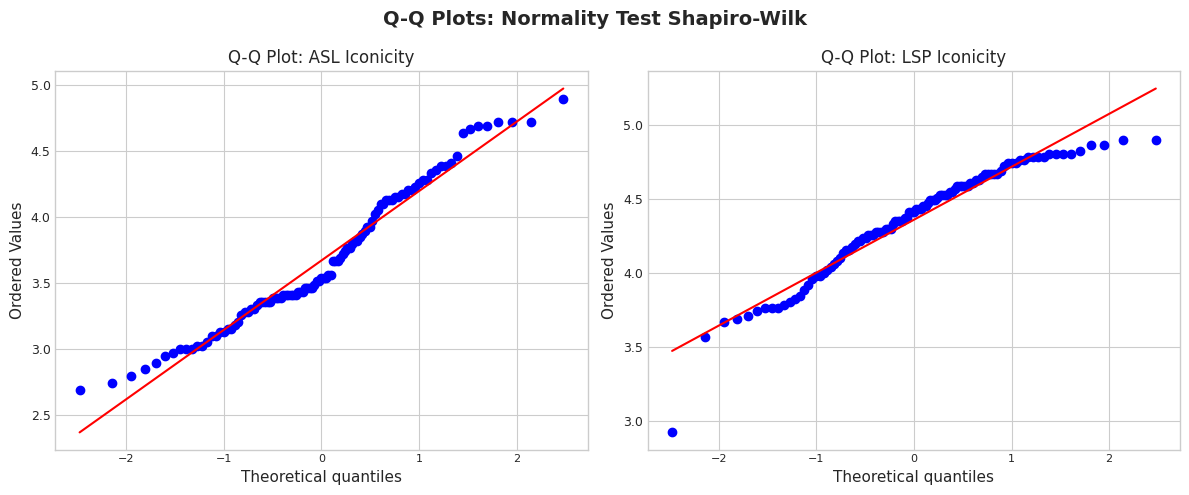

In [39]:
# ============================================================================
# NORMALITY TEST - Shapiro-Wilk
# ============================================================================

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# asl_iconicity and lsp_iconicity

# Normality Test Shapiro-Wilk ---
stat_asl, p_asl = stats.shapiro(asl_iconicity)
stat_lsp, p_lsp = stats.shapiro(lsp_iconicity)

print("- Shapiro-Wilk Normality Test")
print(f"ASL: W = {stat_asl:.4f}, p = {p_asl:.4f} {'Normal' if p_asl > 0.05 else 'No Normal'}")
print(f"LSP: W = {stat_lsp:.4f}, p = {p_lsp:.4f} {'Normal' if p_lsp > 0.05 else 'No Normal'}")

# Q-Q Plots for visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Q-Q Plots: Normality Test Shapiro-Wilk", fontsize=14, fontweight='bold')

stats.probplot(asl_iconicity, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: ASL Iconicity")

stats.probplot(lsp_iconicity, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: LSP Iconicity")

plt.tight_layout()
plt.show()

In [8]:
df_iconicity

,ASL_GLOSS,ASL_ICONICITY,LSP_GLOSS,LSP_ICONICITY
0,BABY,3.820513,BEBÉ,4.254902
1,HOUSE,4.410256,CASA,4.764706
2,GROW,3.897436,CRECER,4.058823
3,SMOKE,4.717949,FUMAR,4.803922
4,WORM,3.384615,GUSANO,4.215686
5,WATCH,4.256410,RELOJ,4.235294
6,EGG,3.282051,HUEVO,4.588235
7,SIT,3.923077,SENTARSE,4.529412
8,SHAMPOO,3.435897,SHAMPOO,4.568627
9,CAT,3.435897,GATO,4.588235


In [9]:
df_embeddings.head(3)

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4054,4055,4056,4057,4058,4059,4060,4061,4062,4063
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,-0.008997,-0.013320,0.037881,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,-0.013641,0.030990,-0.013403,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.013560,-0.013144,-0.007097,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004


In [10]:
df_embeddings.shape

(105, 4066)

In [11]:
# ============================================================================
# STEP 5: Match between name_english and EnglishGloss
# ============================================================================

print("Match between name_english and EnglishGloss ...")
df_mergedTranslate = df_embeddings.merge(
    df_translate[['EnglishGloss', 'SpanishGloss']],
    left_on='ASL_GLOSS',
    right_on='EnglishGloss',
    how='left'
)

# Clean spaces and convert to uppercase to make the match
df_translate['EnglishGloss'] = df_translate['EnglishGloss'].astype(str).str.strip().str.upper()
df_translate['SpanishGloss'] = df_translate['SpanishGloss'].astype(str).str.strip()

Match between name_english and EnglishGloss ...


In [12]:
df_mergedTranslate.shape

(105, 4068)

In [13]:
df_mergedTranslate.head(5)

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4056,4057,4058,4059,4060,4061,4062,4063,EnglishGloss,SpanishGloss
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,0.037881,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625,BABY,BEBÉ
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,-0.013403,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114,CAT,GATO
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.007097,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004,BIRD-CLAW,GARRA-DE-AVE
3,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,0.024008,...,0.048494,-0.014037,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404,RECTANGULAR-PAPER,PAPEL-RECTANGULAR
4,JUMP,SALTAR,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,0.024953,...,-0.013316,0.005038,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027,JUMP,SALTAR


In [14]:
# Both have asl_gloss but distinguishes in the iconicity column to retrieve
if signLanguage == "LSP":
  iconicity_columns = ['ASL_GLOSS', 'LSP_ICONICITY']

elif signLanguage == "ASL":
  iconicity_columns = ['ASL_GLOSS', 'ASL_ICONICITY']


df_mergedIconicity = df_mergedTranslate .merge(
    df_iconicity[iconicity_columns],
    left_on='ASL_GLOSS',
    right_on='ASL_GLOSS',
    how='left'
    )

In [15]:
df_mergedIconicity.columns

Index(['ASL_GLOSS', 'LSP_GLOSS', '0', '1', '2', '3', '4', '5', '6', '7',
       ...
       '4057', '4058', '4059', '4060', '4061', '4062', '4063', 'EnglishGloss',
       'SpanishGloss', 'LSP_ICONICITY'],
      dtype='object', length=4069)

In [16]:
print("Merged Translate", df_mergedTranslate.shape)
print("Merged Iconicity", df_mergedIconicity.shape)


Merged Translate (105, 4068)
Merged Iconicity (105, 4069)


In [17]:
# Validations

df_mergedTranslate.head(5)

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4056,4057,4058,4059,4060,4061,4062,4063,EnglishGloss,SpanishGloss
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,0.037881,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625,BABY,BEBÉ
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,-0.013403,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114,CAT,GATO
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.007097,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004,BIRD-CLAW,GARRA-DE-AVE
3,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,0.024008,...,0.048494,-0.014037,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404,RECTANGULAR-PAPER,PAPEL-RECTANGULAR
4,JUMP,SALTAR,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,0.024953,...,-0.013316,0.005038,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027,JUMP,SALTAR


In [18]:
df_mergedIconicity.head(5)

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4057,4058,4059,4060,4061,4062,4063,EnglishGloss,SpanishGloss,LSP_ICONICITY
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625,BABY,BEBÉ,4.254902
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114,CAT,GATO,4.588235
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004,BIRD-CLAW,GARRA-DE-AVE,4.156863
3,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,0.024008,...,-0.014037,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,2.921569
4,JUMP,SALTAR,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,0.024953,...,0.005038,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027,JUMP,SALTAR,4.863636


In [19]:
df_mergedIconicity.shape

(105, 4069)

In [20]:
# Checking columns with NaN values

nan_counts = df_mergedIconicity.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
check_more = False
if not columns_with_nan.empty:
  print("Columns with NaN values and their counts:")
  print(columns_with_nan)
  check_more = True
else:
  print("No columns with NaN values found in df_mergedIconicity.")

No columns with NaN values found in df_mergedIconicity.


In [21]:
df_iconicity.head(3)

,ASL_GLOSS,ASL_ICONICITY,LSP_GLOSS,LSP_ICONICITY
0,BABY,3.820513,BEBÉ,4.254902
1,HOUSE,4.410256,CASA,4.764706
2,GROW,3.897436,CRECER,4.058823


In [22]:
# ============================================================================
# STEP 6: IF THERE ARE NAN VALUES - DEEPER VALIDATION
# ============================================================================

if check_more:
  words_iconicity = set(df_iconicity['ASL_GLOSS'])
  words_embeddings = set(df_embeddings['ASL_GLOSS'])
 # Finding similarities and differences
  matched_words = words_iconicity & words_embeddings
  only_in_iconicity = words_iconicity - words_embeddings
  only_in_embeddings = words_embeddings - words_iconicity
  print(only_in_iconicity) if len(only_in_iconicity)>0 else 0
  print("📊 RESULTADOS DEL ANÁLISIS")
  print("="*70)
  print(f"✅ Palabras que COINCIDEN: {len(matched_words)}")
  print(f"❌ Solo en ICONICIDAD: {len(only_in_iconicity)}")
  print(f"❌ Solo en EMBEDDINGS: {len(only_in_embeddings)}")
  # Report mismatched words
  if only_in_iconicity:
      print(f"\n🔴 Palabras en ICONICIDAD sin embeddings:")
      for word in sorted(only_in_iconicity):
          iconicity_val = df_iconicity[df_iconicity[signLanguage.lower() +'_gloss'] == word][signLanguage.lower() +'_iconicity'].values[0]
          print(f"   - {word} (iconicity: {iconicity_val:.2f})")

  if only_in_embeddings:
      print(f"\n🔴 Palabras en EMBEDDINGS sin iconicidad:")
      for word in sorted(only_in_embeddings)[:10]:
          print(f"   - {word}")
      if len(only_in_embeddings) > 10:
          print(f"   ... y {len(only_in_embeddings) - 10} más")

In [23]:
extra_cols = []
if signLanguage == "LSP":
  df_final = df_mergedIconicity.rename(columns={'SpanishGloss': 'word', 'LSP_ICONICITY': 'iconicity'})
  extra_cols = ['EnglishGloss']
elif signLanguage == 'ASL':
  df_final = df_mergedIconicity.rename(columns={'ASL_GLOSS': 'word', 'ASL_ICONICITY': 'iconicity'})

In [24]:
df_final.head(3)

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4057,4058,4059,4060,4061,4062,4063,EnglishGloss,word,iconicity
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625,BABY,BEBÉ,4.254902
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114,CAT,GATO,4.588235
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004,BIRD-CLAW,GARRA-DE-AVE,4.156863


In [25]:
extra_cols

['EnglishGloss']

In [26]:
df_final.head(5)

,ASL_GLOSS,LSP_GLOSS,0,1,2,3,4,5,6,7,...,4057,4058,4059,4060,4061,4062,4063,EnglishGloss,word,iconicity
0,BABY,BEBÉ,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,0.024276,...,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625,BABY,BEBÉ,4.254902
1,CAT,GATO,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,0.023365,...,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114,CAT,GATO,4.588235
2,BIRD-CLAW,GARRA-DE-AVE,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,0.023433,...,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004,BIRD-CLAW,GARRA-DE-AVE,4.156863
3,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,0.024008,...,-0.014037,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404,RECTANGULAR-PAPER,PAPEL-RECTANGULAR,2.921569
4,JUMP,SALTAR,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,0.024953,...,0.005038,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027,JUMP,SALTAR,4.863636


In [27]:
needs_rename = False
if needs_rename:
    print("Renaming columns")
    rename_dict = {col: str(int(col[1:])) for col in embedding_cols}
    df_final = df_final.rename(columns=rename_dict)
    embedding_cols_str = [str(int(col[1:])) for col in embedding_cols]
else:
  # Convert embedding_cols (which are currently integers) to strings
  embedding_cols_str = [str(col) for col in embedding_cols]



In [28]:
if extra_cols:
    # It has extra columns (like name_english)
    final_cols = ['word'] + extra_cols + ['iconicity'] + embedding_cols_str
else:
    # Only word, iconicity, embeddings
    final_cols = ['word', 'iconicity'] + embedding_cols_str


df_merged = df_final[final_cols]

In [29]:
df_merged.head(5)

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,4054,4055,4056,4057,4058,4059,4060,4061,4062,4063
0,BEBÉ,BABY,4.254902,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,...,-0.008997,-0.013320,0.037881,-0.013810,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625
1,GATO,CAT,4.588235,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,...,-0.013641,0.030990,-0.013403,0.010236,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114
2,GARRA-DE-AVE,BIRD-CLAW,4.156863,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,...,-0.013560,-0.013144,-0.007097,-0.013633,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004
3,PAPEL-RECTANGULAR,RECTANGULAR-PAPER,2.921569,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,...,-0.000725,-0.013545,0.048494,-0.014037,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404
4,SALTAR,JUMP,4.863636,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,...,-0.011201,0.015393,-0.013316,0.005038,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027


In [30]:
# ============================================================================
# STEP 7: SAVE FILE
# ============================================================================

from google.colab import files
file_type = "csv"
output_filename = output_filename
df_merged.to_csv(output_filename, index=False)

print("\n" + "="*70)
print("="*70)
print(f"   ✓ Archivo guardado: {output_filename}")
print(f"   ✓ Tipo detectado: {file_type}")
print(f"   ✓ Orden de palabras: Según archivo CSV original")
print(f"   ✓ Columnas totales: {len(df_merged.columns)}")
print(f"   ✓ Descargando archivo...")

# Download automatically
files.download(output_filename)



   ✓ Archivo guardado: emb_phono_median_LSP_MHIv5.csv
   ✓ Tipo detectado: csv
   ✓ Orden de palabras: Según archivo CSV original
   ✓ Columnas totales: 4067
   ✓ Descargando archivo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# ============================================================================
# STEP 8: DISPLAY SAMPLE AND STATISTICS
# ============================================================================
print("\n" + "="*70)
print("SAMPLE OF THE FINAL FILE (first 5 words)")
print("="*70)
print(df_merged.iloc[:5, :min(10, len(df_merged.columns))].to_string())

print("\n" + "="*70)
print("STATISTICS")
print("="*70)
print(f"File type: {file_type}")
print(f"Total words: {len(df_merged)}")
print(f"Range of iconicity: {df_merged['iconicity'].min():.2f} - {df_merged['iconicity'].max():.2f}")
print(f"Average iconicity: {df_merged['iconicity'].mean():.2f}")
print(f"Median iconicity: {df_merged['iconicity'].median():.2f}")
print(f"Dimensiones de embeddings: {len(embedding_cols)}")

print("\n First 10 words in order:")
for i, row in df_merged.head(10).iterrows():
    word_display = row['word']
    if 'name_english' in extra_cols and 'name_english' in df_merged.columns:
        word_display = f"{row['word']:15s} ({row['name_english']:12s})"
    else:
        word_display = f"{row['word']:20s}"
    print(f"   {i+1:2d}. {word_display} - iconicity: {row['iconicity']:.2f}")





SAMPLE OF THE FINAL FILE (first 5 words)
                word       EnglishGloss  iconicity         0         1         2         3         4         5         6
0               BEBÉ               BABY   4.254902 -0.003707  0.006492 -0.002747 -0.002082  0.002592  0.000421  0.001634
1               GATO                CAT   4.588235  0.000720  0.002715  0.001315 -0.003357 -0.000763 -0.001859  0.000411
2       GARRA-DE-AVE          BIRD-CLAW   4.156863  0.002340  0.002242  0.002392 -0.005215 -0.002592 -0.004770 -0.001031
3  PAPEL-RECTANGULAR  RECTANGULAR-PAPER   2.921569 -0.004624  0.007973 -0.003322 -0.002185  0.007068  0.000869  0.003827
4             SALTAR               JUMP   4.863636 -0.000006  0.004187  0.000610 -0.003376  0.000010 -0.002249  0.003332

STATISTICS
File type: csv
Total words: 105
Range of iconicity: 2.92 - 4.90
Average iconicity: 4.36
Median iconicity: 4.41
Dimensiones de embeddings: 4064

 First 10 words in order:
    1. BEBÉ                 - iconicity: 4.25
    